In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from xgboost import XGBRegressor
import json
from pathlib import Path
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Config
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.6f}')
np.random.seed(42)
SEED = 42

In [3]:
# Load the full dataset
print("Loading dataset...")
df = pd.read_parquet('data/datasets')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Loading dataset...
Dataset shape: (26482762, 52)
Columns: ['latitude_grid', 'longitude_grid', 'surtep_ERA5', 'fwns', 'Tmn', 'PWV', 'VOD', 'vsm', 'VPD', 'quality_flag', 'ref_land_emis_de_lannoy_K_h', 'ref_land_emis_de_lannoy_K_v', 'tbtoa19V', 'tbtoa19H', 'tbtoa37V', 'tbtoa37H', 'tran19V', 'tran19H', 'tran37V', 'tran37H', 'tbdw19V', 'tbdw19H', 'tbdw37V', 'tbdw37H', 'tbup19V', 'tbup19H', 'tbup37V', 'tbup37H', 'tbboa_1st_order19V', 'tbboa_1st_order19H', 'tbboa_1st_order37V', 'tbboa_1st_order37H', 'tbboa_de_lannoy19V', 'tbboa_de_lannoy19H', 'tbboa_de_lannoy37V', 'tbboa_de_lannoy37H', 'emiss19H_de_lannoy', 'emiss19V_de_lannoy', 'emiss37H_de_lannoy', 'emiss37V_de_lannoy', 'denominator', 'term_1', 'term_2', 'fwns_calculated', 'clase', 'porcentaje clase', 'day_of_year', 'year', 'doy_sin', 'doy_cos', 'lon_sin', 'lon_cos']

Data types:
latitude_grid                  float32
longitude_grid                 float32
surtep_ERA5                    float32
fwns                           float32
Tmn    

In [4]:
# Sort by spatial location and time
print("Sorting data by location and time...")
df = df.sort_values(['latitude_grid', 'longitude_grid', 'year', 'day_of_year']).reset_index(drop=True)

# Define columns to lag
LAG_COLUMNS = [
    'tbtoa19H', 'tbtoa19V', 'tbtoa37H', 'tbtoa37V',
    'emiss19H_de_lannoy', 'emiss19V_de_lannoy', 'emiss37H_de_lannoy', 'emiss37V_de_lannoy',
    'Tmn', 'PWV', 'VPD', 'vsm', 'VOD', 'surtep_ERA5',
    'fwns', 'fwns_calculated'
]

# Create lag-1 features grouped by pixel (lat, lon)
print("Creating lag-1 features...")
for col in LAG_COLUMNS:
    df[f'{col}_lag1'] = df.groupby(['latitude_grid', 'longitude_grid'])[col].shift(1)

# Handle year boundary: NaN out lag features for first observation of each pixel each year
# Check if this is the first observation of a pixel in a new year
df['year_group'] = df.groupby(['latitude_grid', 'longitude_grid'])['year'].shift(1)
year_boundary_mask = df['year'] != df['year_group']

# Also mark first row overall and rows after missing data gaps
first_row_per_group = df.groupby(['latitude_grid', 'longitude_grid']).cumcount() == 0

# NaN out lag features for year boundaries
for col in LAG_COLUMNS:
    df.loc[year_boundary_mask | first_row_per_group, f'{col}_lag1'] = np.nan

df = df.drop(columns=['year_group'])

print(f"Dataset shape after lag creation: {df.shape}")
print(f"\nLag feature NaN counts:")
lag_cols = [f'{col}_lag1' for col in LAG_COLUMNS]
print(df[lag_cols].isna().sum())

# Drop rows with any NaN lag feature
df_clean = df.dropna(subset=lag_cols)
print(f"\nDataset shape after dropping NaN lags: {df_clean.shape}")
print(f"Dropped {df.shape[0] - df_clean.shape[0]} rows ({100*(df.shape[0] - df_clean.shape[0])/df.shape[0]:.2f}%)")
df = df_clean

Sorting data by location and time...
Creating lag-1 features...
Dataset shape after lag creation: (26482762, 68)

Lag feature NaN counts:
tbtoa19H_lag1              446269
tbtoa19V_lag1              446269
tbtoa37H_lag1              446269
tbtoa37V_lag1              446269
emiss19H_de_lannoy_lag1    446269
emiss19V_de_lannoy_lag1    446269
emiss37H_de_lannoy_lag1    446269
emiss37V_de_lannoy_lag1    446269
Tmn_lag1                   446269
PWV_lag1                   446269
VPD_lag1                   446269
vsm_lag1                   446269
VOD_lag1                   446269
surtep_ERA5_lag1           446269
fwns_lag1                  446269
fwns_calculated_lag1       446269
dtype: int64

Dataset shape after dropping NaN lags: (26036493, 68)
Dropped 446269 rows (1.69%)


In [6]:
# Year-based split: 2017 = train, 2018 = test
train_df = df[df['year'] == 2017].copy()
test_df = df[df['year'] == 2018].copy()

print(f"Train set (2017): {train_df.shape[0]} rows")
print(f"Test set (2018): {test_df.shape[0]} rows")
print(f"\nTrain / Total split: {100*train_df.shape[0]/(train_df.shape[0]+test_df.shape[0]):.1f}%")

Train set (2017): 12614851 rows
Test set (2018): 13421642 rows

Train / Total split: 48.5%


In [8]:
# Load best XGBoost hyperparameters
with open('HPO_results/best_xgb_params.json') as f:
    best_params = json.load(f)

print("Best XGBoost hyperparameters:")
for key, val in best_params.items():
    print(f"  {key}: {val}")

Best XGBoost hyperparameters:
  max_depth: 14
  learning_rate: 0.07611006029948317
  min_child_weight: 1.2565430356668845
  subsample: 0.9202046048327591
  colsample_bytree: 0.918987068135406
  gamma: 5.234946485327852e-06
  reg_alpha: 5.842901406255101e-06
  reg_lambda: 6.790110973880345
  objective: reg:squarederror
  eval_metric: rmse
  tree_method: hist
  device: cuda
  random_state: 42


In [20]:
# Define feature sets
BASELINE_FEATURES = [
    'latitude_grid',
    'Tmn', 'PWV', 'VOD', 'vsm', 'VPD', 'surtep_ERA5',
    'tran19V', 'tran37V', 'tbup19V', 'tbup37V',
    'emiss19H_de_lannoy', 'emiss19V_de_lannoy',
    'emiss37H_de_lannoy', 'emiss37V_de_lannoy',
    'tbtoa19H', 'tbtoa19V', 'tbtoa37H', 'tbtoa37V',
    'ref_land_emis_de_lannoy_K_h', 'ref_land_emis_de_lannoy_K_v',
    'denominator',
    'fwns_calculated',
    'doy_sin',
]

LAG_FEATURES = [
    'tbtoa19H_lag1', 'tbtoa19V_lag1', 'tbtoa37H_lag1', 'tbtoa37V_lag1',
    'emiss19H_de_lannoy_lag1', 'emiss19V_de_lannoy_lag1',
    'emiss37H_de_lannoy_lag1', 'emiss37V_de_lannoy_lag1',
    'Tmn_lag1', 'PWV_lag1', 'VPD_lag1',
    'vsm_lag1', 'VOD_lag1', 'surtep_ERA5_lag1',
    # 'fwns_lag1',
    'fwns_calculated_lag1',
]

TEMPORAL_FEATURES = BASELINE_FEATURES + LAG_FEATURES

print(f"Baseline features: {len(BASELINE_FEATURES)} features")
print(f"Lag features: {len(LAG_FEATURES)} features")
print(f"Temporal features (total): {len(TEMPORAL_FEATURES)} features")
print(f"\nBaseline features: {BASELINE_FEATURES}")
print(f"\nLag features: {LAG_FEATURES}")

Baseline features: 24 features
Lag features: 15 features
Temporal features (total): 39 features

Baseline features: ['latitude_grid', 'Tmn', 'PWV', 'VOD', 'vsm', 'VPD', 'surtep_ERA5', 'tran19V', 'tran37V', 'tbup19V', 'tbup37V', 'emiss19H_de_lannoy', 'emiss19V_de_lannoy', 'emiss37H_de_lannoy', 'emiss37V_de_lannoy', 'tbtoa19H', 'tbtoa19V', 'tbtoa37H', 'tbtoa37V', 'ref_land_emis_de_lannoy_K_h', 'ref_land_emis_de_lannoy_K_v', 'denominator', 'fwns_calculated', 'doy_sin']

Lag features: ['tbtoa19H_lag1', 'tbtoa19V_lag1', 'tbtoa37H_lag1', 'tbtoa37V_lag1', 'emiss19H_de_lannoy_lag1', 'emiss19V_de_lannoy_lag1', 'emiss37H_de_lannoy_lag1', 'emiss37V_de_lannoy_lag1', 'Tmn_lag1', 'PWV_lag1', 'VPD_lag1', 'vsm_lag1', 'VOD_lag1', 'surtep_ERA5_lag1', 'fwns_calculated_lag1']


In [13]:
# Train baseline model (no lag features)
print("\n" + "="*60)
print("Training BASELINE model (no temporal context)...")
print("="*60)

X_train_baseline = train_df[BASELINE_FEATURES]
y_train = train_df['fwns']
X_test_baseline = test_df[BASELINE_FEATURES]
y_test = test_df['fwns']

print(f"X_train shape: {X_train_baseline.shape}")
print(f"X_test shape: {X_test_baseline.shape}")

# Create and train model
baseline_model = XGBRegressor(**best_params)
baseline_model.fit(
    X_train_baseline, y_train,
    eval_set=[(X_test_baseline, y_test)],
    verbose=False
)

# Evaluate
y_pred_baseline = baseline_model.predict(X_test_baseline)
baseline_r2 = r2_score(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)

print(f"\nBaseline Model Results:")
print(f"  R² Score: {baseline_r2:.6f}")
print(f"  RMSE: {baseline_rmse:.6f}")
print(f"  MAE: {baseline_mae:.6f}")


Training BASELINE model (no temporal context)...
X_train shape: (12614851, 24)
X_test shape: (13421642, 24)


c:\Users\marce\miniconda3\envs\TFM_MCD\Lib\site-packages\xgboost\core.py:158: UserWarning: [20:21:06] WARNING: D:\bld\xgboost-split_1744329000128\work\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)



Baseline Model Results:
  R² Score: 0.923694
  RMSE: 0.016160
  MAE: 0.009010


In [21]:
# Train temporal model (with lag features)
print("\n" + "="*60)
print("Training TEMPORAL model (with lag features)...")
print("="*60)

X_train_temporal = train_df[TEMPORAL_FEATURES]
X_test_temporal = test_df[TEMPORAL_FEATURES]

print(f"X_train shape: {X_train_temporal.shape}")
print(f"X_test shape: {X_test_temporal.shape}")

# Create and train model
temporal_model = XGBRegressor(**best_params)
temporal_model.fit(
    X_train_temporal, y_train,
    eval_set=[(X_test_temporal, y_test)],
    verbose=False
)

# Evaluate
y_pred_temporal = temporal_model.predict(X_test_temporal)
temporal_r2 = r2_score(y_test, y_pred_temporal)
temporal_rmse = np.sqrt(mean_squared_error(y_test, y_pred_temporal))
temporal_mae = mean_absolute_error(y_test, y_pred_temporal)

print(f"\nTemporal Model Results:")
print(f"  R² Score: {temporal_r2:.6f}")
print(f"  RMSE: {temporal_rmse:.6f}")
print(f"  MAE: {temporal_mae:.6f}")


Training TEMPORAL model (with lag features)...
X_train shape: (12614851, 39)
X_test shape: (13421642, 39)

Temporal Model Results:
  R² Score: 0.929192
  RMSE: 0.015567
  MAE: 0.008763


In [22]:
# Create comparison table
results_df = pd.DataFrame({
    'Model': ['Baseline (no lag)', 'Temporal (with lag)'],
    'Features': [len(BASELINE_FEATURES), len(TEMPORAL_FEATURES)],
    'R² Score': [baseline_r2, temporal_r2],
    'RMSE': [baseline_rmse, temporal_rmse],
    'MAE': [baseline_mae, temporal_mae],
})

results_df['ΔR² (%)'] = (results_df['R² Score'] - baseline_r2) * 100
results_df['ΔRMSE (%)'] = (results_df['RMSE'] - baseline_rmse) / baseline_rmse * 100

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(results_df.to_string(index=False))

# Calculate improvement
r2_improvement = (temporal_r2 - baseline_r2) / baseline_r2 * 100
rmse_improvement = (baseline_rmse - temporal_rmse) / baseline_rmse * 100
mae_improvement = (baseline_mae - temporal_mae) / baseline_mae * 100

print(f"\nImprovement Summary:")
print(f"  R² improvement: {r2_improvement:+.3f}%")
print(f"  RMSE improvement: {rmse_improvement:+.3f}%")
print(f"  MAE improvement: {mae_improvement:+.3f}%")


MODEL COMPARISON
              Model  Features  R² Score     RMSE      MAE  ΔR² (%)  ΔRMSE (%)
  Baseline (no lag)        24  0.923694 0.016160 0.009010 0.000000   0.000000
Temporal (with lag)        39  0.929192 0.015567 0.008763 0.549793  -3.669941

Improvement Summary:
  R² improvement: +0.595%
  RMSE improvement: +3.670%
  MAE improvement: +2.743%



Computing SHAP feature importance for temporal model...
(This may take a few minutes on a large dataset)


C:\Users\marce\AppData\Local\Temp\ipykernel_13460\247745623.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)


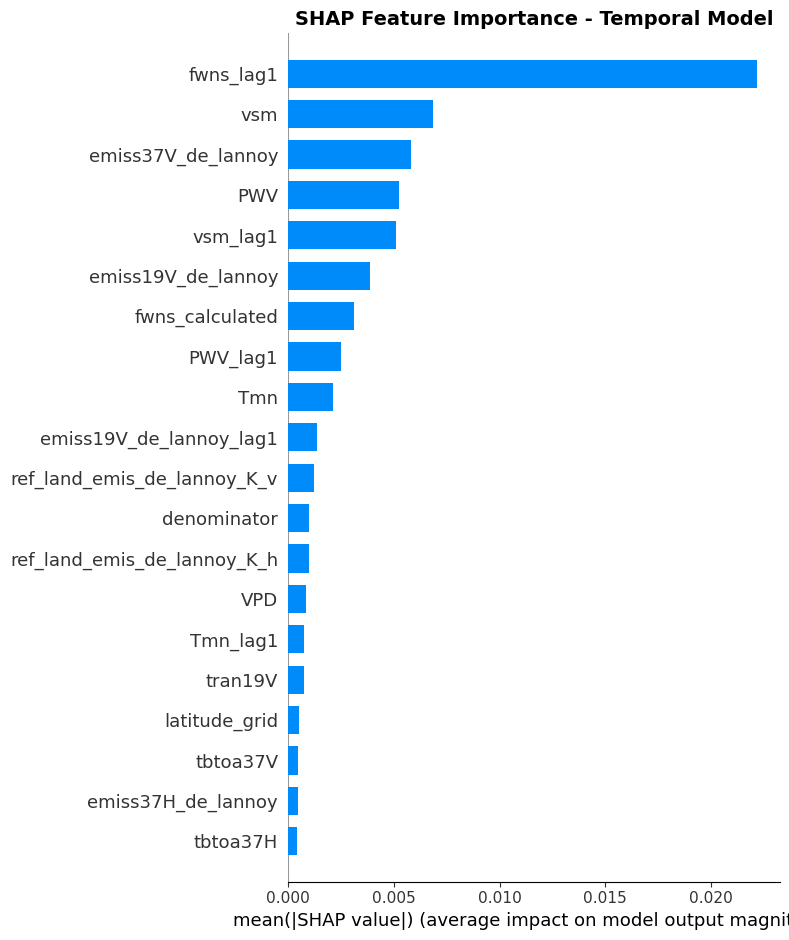


Top 20 features by SHAP importance:
                    Feature  Mean |SHAP|
                  fwns_lag1     0.022144
                        vsm     0.006872
         emiss37V_de_lannoy     0.005822
                        PWV     0.005269
                   vsm_lag1     0.005114
         emiss19V_de_lannoy     0.003879
            fwns_calculated     0.003143
                   PWV_lag1     0.002489
                        Tmn     0.002146
    emiss19V_de_lannoy_lag1     0.001373
ref_land_emis_de_lannoy_K_v     0.001234
                denominator     0.000984
ref_land_emis_de_lannoy_K_h     0.000982
                        VPD     0.000853
                   Tmn_lag1     0.000777
                    tran19V     0.000777
              latitude_grid     0.000511
                   tbtoa37V     0.000460
         emiss37H_de_lannoy     0.000460
                   tbtoa37H     0.000423


In [ ]:
# SHAP feature importance for temporal model
print("\nComputing SHAP feature importance for temporal model...")
print("(This may take a few minutes on a large dataset)")

# Use a sample for SHAP computation (due to computational cost)
sample_size = min(5000, len(X_test_temporal))
sample_indices = np.random.choice(len(X_test_temporal), sample_size, replace=False)
X_sample = X_test_temporal.iloc[sample_indices]

# Create TreeExplainer
explainer = shap.TreeExplainer(temporal_model)
shap_values = explainer.shap_values(X_sample)

# Plot feature importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance - Temporal Model", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top features
feature_importance_df = pd.DataFrame({
    'Feature': TEMPORAL_FEATURES,
    'Mean |SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False)

print("\nTop 20 features by SHAP importance:")
print(feature_importance_df.head(20).to_string(index=False))

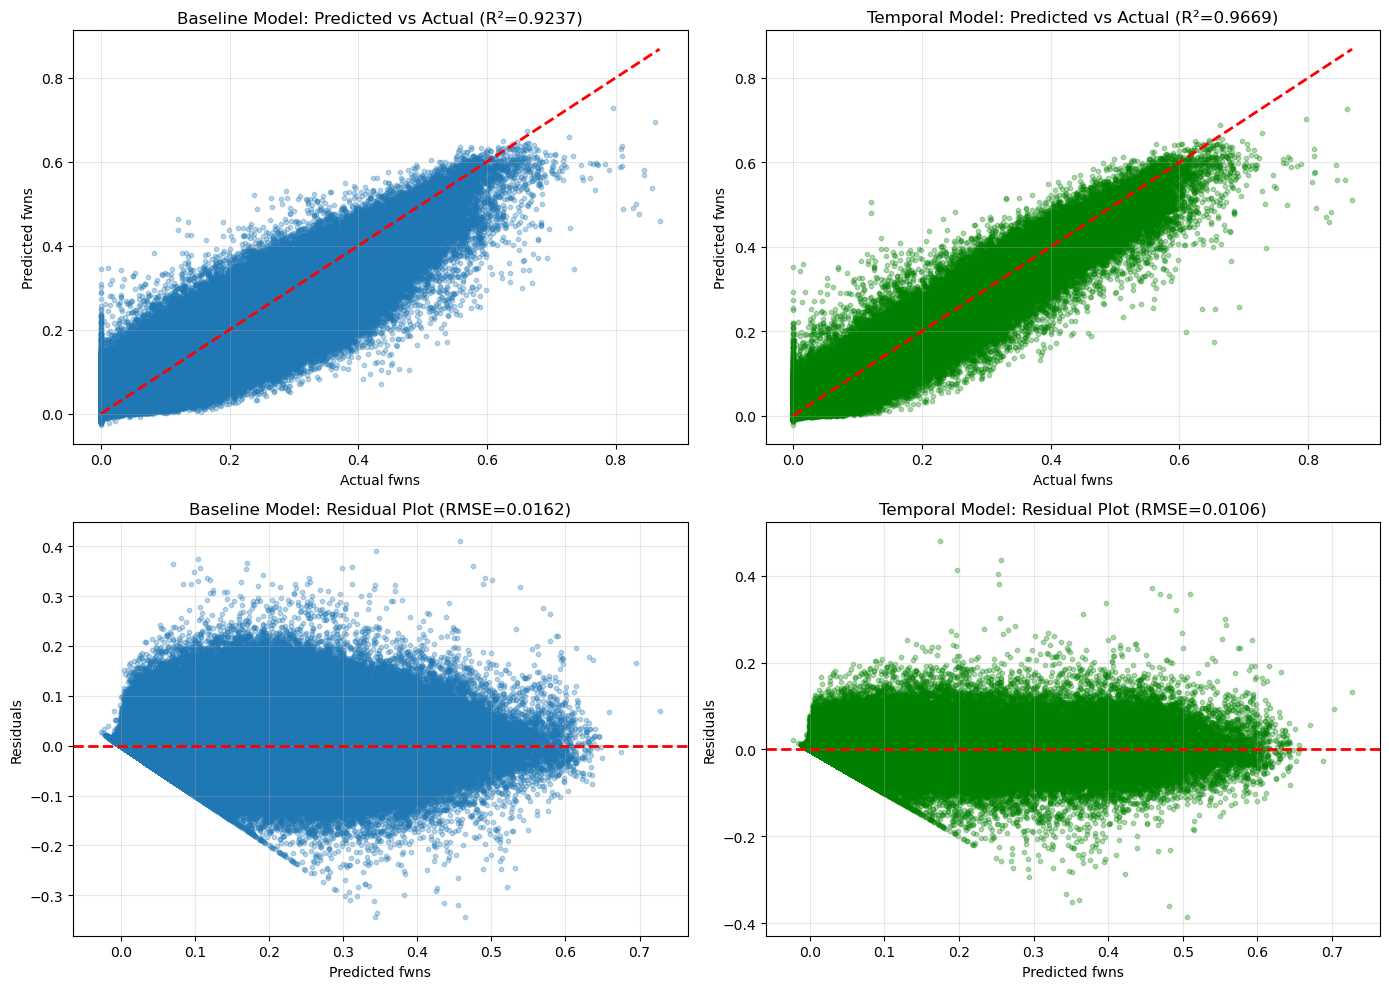

In [18]:
# Residual plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Baseline: Predicted vs Actual
axes[0, 0].scatter(y_test, y_pred_baseline, alpha=0.3, s=10)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual fwns')
axes[0, 0].set_ylabel('Predicted fwns')
axes[0, 0].set_title(f'Baseline Model: Predicted vs Actual (R²={baseline_r2:.4f})')
axes[0, 0].grid(True, alpha=0.3)

# Temporal: Predicted vs Actual
axes[0, 1].scatter(y_test, y_pred_temporal, alpha=0.3, s=10, color='green')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual fwns')
axes[0, 1].set_ylabel('Predicted fwns')
axes[0, 1].set_title(f'Temporal Model: Predicted vs Actual (R²={temporal_r2:.4f})')
axes[0, 1].grid(True, alpha=0.3)

# Baseline: Residuals
residuals_baseline = y_test - y_pred_baseline
axes[1, 0].scatter(y_pred_baseline, residuals_baseline, alpha=0.3, s=10)
axes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted fwns')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title(f'Baseline Model: Residual Plot (RMSE={baseline_rmse:.4f})')
axes[1, 0].grid(True, alpha=0.3)

# Temporal: Residuals
residuals_temporal = y_test - y_pred_temporal
axes[1, 1].scatter(y_pred_temporal, residuals_temporal, alpha=0.3, s=10, color='green')
axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Predicted fwns')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title(f'Temporal Model: Residual Plot (RMSE={temporal_rmse:.4f})')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# Save the temporal model
print("\nSaving models and results...")
temporal_model.save_model('models/temporal_xgb.json')
print("[OK] Temporal model saved to models/temporal_xgb.json")

baseline_model.save_model('models/baseline_xgb.json')
print("[OK] Baseline model saved to models/baseline_xgb.json")

# Save results summary
results_summary = {
    'baseline': {
        'features': BASELINE_FEATURES,
        'num_features': len(BASELINE_FEATURES),
        'r2_score': float(baseline_r2),
        'rmse': float(baseline_rmse),
        'mae': float(baseline_mae),
    },
    'temporal': {
        'features': TEMPORAL_FEATURES,
        'num_features': len(TEMPORAL_FEATURES),
        'r2_score': float(temporal_r2),
        'rmse': float(temporal_rmse),
        'mae': float(temporal_mae),
    },
    'improvement': {
        'r2_improvement_pct': float(r2_improvement),
        'rmse_improvement_pct': float(rmse_improvement),
        'mae_improvement_pct': float(mae_improvement),
    }
}

import os
os.makedirs('results', exist_ok=True)
with open('results/temporal_context_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print("[OK] Results summary saved to results/temporal_context_results.json")


Saving models and results...
[OK] Temporal model saved to models/temporal_xgb.json
[OK] Baseline model saved to models/baseline_xgb.json
[OK] Results summary saved to results/temporal_context_results.json
